In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve, precision_score, recall_score)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
import shap

# Import custom HLA matching module
import sys
sys.path.append('utils')
from hla_matching import HLAMatcher, compute_hla_matches
from shap_explainer import DonorMatchExplainer, create_explainer



 1. Data Loading and Preparation

 HLA Compatibility Preprocessing 

In [11]:
# Initialize HLA matcher
hla_matcher = HLAMatcher()

# Load dataset
df = pd.read_csv('kidney_donor_dataset.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())

# Compute HLA match scores dynamically
print("\n" + "="*70)
print("COMPUTING HLA MATCH SCORES (RULE-BASED)")
print("="*70)

hla_scores, hla_qualities = compute_hla_matches(
    df['Donor_HLA_Typing'], 
    df['Recipient_HLA_Typing']
)

# Add HLA score as derived feature
df['HLA_Match_Score'] = hla_scores
df['HLA_Match_Quality'] = hla_qualities

print(f"\nHLA Match Score Distribution:")
print(df['HLA_Match_Score'].value_counts().sort_index())

print(f"\nHLA Match Quality Distribution:")
print(df['HLA_Match_Quality'].value_counts())

# Display sample HLA matching results
print("\n" + "="*70)
print("SAMPLE HLA MATCHING RESULTS (First 5 pairs)")
print("="*70)
for idx in range(min(5, len(df))):
    result = hla_matcher.compute_match_with_details(
        df.loc[idx, 'Donor_HLA_Typing'],
        df.loc[idx, 'Recipient_HLA_Typing']
    )
    print(f"\nPair {idx + 1}:")
    print(f"  Donor HLA:     {df.loc[idx, 'Donor_HLA_Typing']}")
    print(f"  Recipient HLA: {df.loc[idx, 'Recipient_HLA_Typing']}")
    print(f"  Match Score:   {result['HLA_Match_Score']}/6 ({result['Match_Quality']})")
    print(f"  Breakdown:     HLA-A: {result['Locus_Breakdown']['A']}, "
          f"HLA-B: {result['Locus_Breakdown']['B']}, "
          f"HLA-DR: {result['Locus_Breakdown']['DR']}")



Dataset shape: (1000, 19)

First few rows:
   Donor_Age  Donor_BMI  Donor_eGFR  Donor_HTN  Donor_DM Donor_ABO  \
0         25       22.8       113.3          1         0         B   
1         39       25.2       104.4          0         0        AB   
2         33       29.8        62.5          0         0        AB   
3         38       30.5        60.0          0         0         A   
4         60       33.0       120.7          1         0        AB   

          Donor_HLA_Typing  Recipient_Age Recipient_ABO  Recipient_PRA  \
0   A3,A3,B27,B27,DR3,DR15             46             O           53.9   
1     A1,A3,B44,B7,DR3,DR4             41             O           96.5   
2  A11,A24,B7,B27,DR4,DR15             19             A           17.6   
3   A2,A1,B27,B27,DR15,DR7             36             A           27.2   
4    A11,A3,B7,B35,DR1,DR3             39            AB           74.9   

   Dialysis_Years     Recipient_HLA_Typing  ABO_Compatibility  Age_Gap  \
0             5.1

 Data Loading and Target Preparation

In [12]:
# Identify target column
if 'match_label' in df.columns:
    target_col = 'match_label'
elif 'Suitability' in df.columns:
    target_col = 'Suitability'
else:
    target_col = df.columns[-1]

# Convert target to binary format
if df[target_col].dtype == 'object':
    df['target'] = df[target_col].apply(lambda x: 1 if 'Suitable' in str(x) else 0)
else:
    df['target'] = df[target_col]

print(f"\nTarget column: {target_col}")
print(f"\nClass distribution:")
print(df['target'].value_counts())
print(f"Balance: {df['target'].value_counts(normalize=True).to_dict()}")

# Verify ABO compatibility is binary (deterministic, not learned)
print(f"\nABO Compatibility Distribution:")
print(df['ABO_Compatibility'].value_counts())
print("\n✓ ABO compatibility is binary (0=Incompatible, 1=Compatible)")
print("✓ Both HLA and ABO matching are rule-based, not ML-learned")


Target column: Suitability

Class distribution:
target
0    697
1    303
Name: count, dtype: int64
Balance: {0: 0.697, 1: 0.303}

ABO Compatibility Distribution:
ABO_Compatibility
1    539
0    461
Name: count, dtype: int64

✓ ABO compatibility is binary (0=Incompatible, 1=Compatible)
✓ Both HLA and ABO matching are rule-based, not ML-learned


2. Feature Engineering and Preprocessing



In [13]:
# Define columns to exclude from features
exclude_cols = [
    'target', target_col, 'donor_id', 'Donor_ID', 'Recipient_ID',
    'Donor_HLA_Typing', 'Recipient_HLA_Typing',  # Raw HLA strings excluded
    'HLA_Match_Quality',  # Qualitative label excluded (use numeric score)
    'Compatibility_Index', 'Risk_Probability', 'Risk_Category'  # Derived columns excluded
]

# Select feature columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print("="*70)
print("FEATURE SELECTION")
print("="*70)
print(f"\nTotal features: {len(feature_cols)}")
print(f"\nSelected features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

# Identify numeric and categorical features
numeric_features = df[feature_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}):")
for feat in numeric_features:
    print(f"  - {feat}")

print(f"\nCategorical features ({len(categorical_features)}):")
for feat in categorical_features:
    print(f"  - {feat}")

# Verify rule-based features are included
print("\n" + "="*70)
print("RULE-BASED FEATURES VERIFICATION")
print("="*70)
if 'HLA_Match_Score' in numeric_features:
    print("✓ HLA_Match_Score included (rule-based, 0-6)")
if 'ABO_Compatibility' in numeric_features:
    print("✓ ABO_Compatibility included (rule-based, binary)")

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("\n✓ Preprocessing pipeline created")
print("="*70)

FEATURE SELECTION

Total features: 14

Selected features:
   1. Donor_Age
   2. Donor_BMI
   3. Donor_eGFR
   4. Donor_HTN
   5. Donor_DM
   6. Donor_ABO
   7. Recipient_Age
   8. Recipient_ABO
   9. Recipient_PRA
  10. Dialysis_Years
  11. ABO_Compatibility
  12. Age_Gap
  13. Donor_Risk_Index
  14. HLA_Match_Score

Numeric features (12):
  - Donor_Age
  - Donor_BMI
  - Donor_eGFR
  - Donor_HTN
  - Donor_DM
  - Recipient_Age
  - Recipient_PRA
  - Dialysis_Years
  - ABO_Compatibility
  - Age_Gap
  - Donor_Risk_Index
  - HLA_Match_Score

Categorical features (2):
  - Donor_ABO
  - Recipient_ABO

RULE-BASED FEATURES VERIFICATION
✓ HLA_Match_Score included (rule-based, 0-6)
✓ ABO_Compatibility included (rule-based, binary)

✓ Preprocessing pipeline created


C:\Users\CNN COMPUTERS\AppData\Local\Temp\ipykernel_1216\2654375750.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()


3. Model Training



In [14]:
# Prepare feature matrix and target
X = df[feature_cols]
y = df['target']

# Split data (stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("="*70)
print("DATA SPLIT")
print("="*70)
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in test set:")
print(y_test.value_counts())

# Build Random Forest pipeline (PRIMARY MODEL)
print("\n" + "="*70)
print("TRAINING RANDOM FOREST (PRIMARY MODEL)")
print("="*70)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=35,
        max_depth=3,
        min_samples_split=35,
        min_samples_leaf=25,
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)
print("✓ Random Forest training complete")
print("="*70)

DATA SPLIT
Training set: 750 samples
Test set: 250 samples

Class distribution in training set:
target
0    523
1    227
Name: count, dtype: int64

Class distribution in test set:
target
0    174
1     76
Name: count, dtype: int64

TRAINING RANDOM FOREST (PRIMARY MODEL)
✓ Random Forest training complete


4. Model Evaluation



In [15]:
# Generate predictions
y_pred = model_pipeline.predict(X_test)
y_probs = model_pipeline.predict_proba(X_test)[:, 1]


acc = accuracy_score(y_test, y_pred)
roc_val = roc_auc_score(y_test, y_probs)

print("="*60)
print("MODEL PERFORMANCE REPORT")
print("="*60)
print(f"\nROC-AUC Score: {roc_val:.4f}")
print(f"Accuracy: {acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(f"TN: {cm[0,0]:4d}  |  FP: {cm[0,1]:4d}")
print(f"FN: {cm[1,0]:4d}  |  TP: {cm[1,1]:4d}")
print("="*60)

MODEL PERFORMANCE REPORT

ROC-AUC Score: 0.9086
Accuracy: 89.20%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.91      0.94      0.92       174
    Suitable       0.86      0.78      0.81        76

    accuracy                           0.89       250
   macro avg       0.88      0.86      0.87       250
weighted avg       0.89      0.89      0.89       250


Confusion Matrix:
TN:  164  |  FP:   10
FN:   17  |  TP:   59


In [16]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

# Store Random Forest results
rf_acc = acc
rf_roc = roc_val
rf_y_pred = y_pred
rf_y_probs = y_probs

print("Random Forest results stored for comparison")

Random Forest results stored for comparison


Model 2: Logistic Regression

In [17]:
# Create Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])


lr_pipeline.fit(X_train, y_train)

# Generate predictions
lr_y_pred = lr_pipeline.predict(X_test)
lr_y_probs = lr_pipeline.predict_proba(X_test)[:, 1]


lr_acc = accuracy_score(y_test, lr_y_pred)
lr_roc = roc_auc_score(y_test, lr_y_probs)

print("="*60)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {lr_roc:.4f}")
print(f"Accuracy: {lr_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, lr_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
lr_cm = confusion_matrix(y_test, lr_y_pred)
print(f"TN: {lr_cm[0,0]:4d}  |  FP: {lr_cm[0,1]:4d}")
print(f"FN: {lr_cm[1,0]:4d}  |  TP: {lr_cm[1,1]:4d}")
print("="*60)

LOGISTIC REGRESSION PERFORMANCE

ROC-AUC Score: 0.8970
Accuracy: 88.40%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.92      0.91      0.92       174
    Suitable       0.80      0.83      0.81        76

    accuracy                           0.88       250
   macro avg       0.86      0.87      0.86       250
weighted avg       0.89      0.88      0.88       250


Confusion Matrix:
TN:  158  |  FP:   16
FN:   13  |  TP:   63


 Model 3:Gradient Boosting Classifier

In [18]:

gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=120,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])


gb_pipeline.fit(X_train, y_train)


gb_y_pred = gb_pipeline.predict(X_test)
gb_y_probs = gb_pipeline.predict_proba(X_test)[:, 1]


gb_acc = accuracy_score(y_test, gb_y_pred)
gb_roc = roc_auc_score(y_test, gb_y_probs)

print("="*60)
print("GRADIENT BOOSTING PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {gb_roc:.4f}")
print(f"Accuracy: {gb_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, gb_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
gb_cm = confusion_matrix(y_test, gb_y_pred)
print(f"TN: {gb_cm[0,0]:4d}  |  FP: {gb_cm[0,1]:4d}")
print(f"FN: {gb_cm[1,0]:4d}  |  TP: {gb_cm[1,1]:4d}")
print("="*60)

GRADIENT BOOSTING PERFORMANCE

ROC-AUC Score: 0.8757
Accuracy: 93.20%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.92      0.99      0.95       174
    Suitable       0.98      0.79      0.88        76

    accuracy                           0.93       250
   macro avg       0.95      0.89      0.91       250
weighted avg       0.94      0.93      0.93       250


Confusion Matrix:
TN:  173  |  FP:    1
FN:   16  |  TP:   60


Model 4:Support Vector Machine 

In [19]:

svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])


svm_pipeline.fit(X_train, y_train)


svm_y_pred = svm_pipeline.predict(X_test)
svm_y_probs = svm_pipeline.predict_proba(X_test)[:, 1]


svm_acc = accuracy_score(y_test, svm_y_pred)
svm_roc = roc_auc_score(y_test, svm_y_probs)

print("="*60)
print("SUPPORT VECTOR MACHINE PERFORMANCE")
print("="*60)
print(f"\nROC-AUC Score: {svm_roc:.4f}")
print(f"Accuracy: {svm_acc * 100:.2f}%")

print("\n" + "-"*60)
print("Classification Report:")
print("-"*60)
print(classification_report(y_test, svm_y_pred, target_names=['Not Suitable', 'Suitable']))

print("\nConfusion Matrix:")
svm_cm = confusion_matrix(y_test, svm_y_pred)
print(f"TN: {svm_cm[0,0]:4d}  |  FP: {svm_cm[0,1]:4d}")
print(f"FN: {svm_cm[1,0]:4d}  |  TP: {svm_cm[1,1]:4d}")
print("="*60)

SUPPORT VECTOR MACHINE PERFORMANCE

ROC-AUC Score: 0.8950
Accuracy: 88.40%

------------------------------------------------------------
Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Suitable       0.91      0.92      0.92       174
    Suitable       0.81      0.80      0.81        76

    accuracy                           0.88       250
   macro avg       0.86      0.86      0.86       250
weighted avg       0.88      0.88      0.88       250


Confusion Matrix:
TN:  160  |  FP:   14
FN:   15  |  TP:   61


 4.2Model Comparison and Selection




In [20]:
# Create comparison dataframe
comparison_data = {
    'Model': ['Random Forest', 'Logistic Regression', 'Gradient Boosting', 'SVM (RBF)'],
    'Accuracy': [rf_acc, lr_acc, gb_acc, svm_acc],
    'ROC-AUC': [rf_roc, lr_roc, gb_roc, svm_roc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Select best model based on ROC-AUC
best_idx = comparison_df['ROC-AUC'].idxmax()
best_model_name = comparison_df.loc[best_idx, 'Model']
best_roc_auc = comparison_df.loc[best_idx, 'ROC-AUC']
best_accuracy = comparison_df.loc[best_idx, 'Accuracy']

print(f"\n SELECTED MODEL: {best_model_name}")
print(f"   ROC-AUC: {best_roc_auc:.4f}")
print(f"   Accuracy: {best_accuracy * 100:.2f}%")
print("="*70)


model_map = {
    'Random Forest': model_pipeline,
    'Logistic Regression': lr_pipeline,
    'Gradient Boosting': gb_pipeline,
    'SVM (RBF)': svm_pipeline
}

final_model = model_map[best_model_name]
print(f"\nFinal model pipeline ready for deployment")

MODEL COMPARISON SUMMARY
              Model  Accuracy  ROC-AUC
      Random Forest     0.892 0.908575
Logistic Regression     0.884 0.897005
          SVM (RBF)     0.884 0.894964
  Gradient Boosting     0.932 0.875681

 SELECTED MODEL: Random Forest
   ROC-AUC: 0.9086
   Accuracy: 89.20%

Final model pipeline ready for deployment


4.3Final Model Selection and Justification

In [21]:
# Select Random Forest as final model
# (Based on interpretability, SHAP compatibility, and clinical utility)
final_model = model_pipeline
final_model_name = "Random Forest"
final_roc_auc = rf_roc
final_accuracy = rf_acc

print("="*70)
print("FINAL MODEL SELECTION")
print("="*70)
print(f"Selected Model: {final_model_name}")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"Accuracy: {final_accuracy * 100:.2f}%")
print("\nSelection Criteria:")
print("  ✓ Competitive predictive performance")
print("  ✓ High clinical interpretability")
print("  ✓ Native SHAP TreeExplainer support")
print("  ✓ Handles non-linear interactions")
print("  ✓ Robust to overfitting with proper tuning")
print("="*70)

FINAL MODEL SELECTION
Selected Model: Random Forest
ROC-AUC: 0.9086
Accuracy: 89.20%

Selection Criteria:
  ✓ Competitive predictive performance
  ✓ High clinical interpretability
  ✓ Native SHAP TreeExplainer support
  ✓ Handles non-linear interactions
  ✓ Robust to overfitting with proper tuning


 5. Final Model Persistence



In [22]:
# Note: Model saving is performed at the end of the notebook (Section 12)
# This cell is preserved for reference but does not save a model
print("⚠️ Intermediate model saving disabled")
print("✓ Final model will be saved in Section 12 only")

⚠️ Intermediate model saving disabled
✓ Final model will be saved in Section 12 only


6. Model Comparison Visualization

Visualization saved: model_comparison_analysis.png


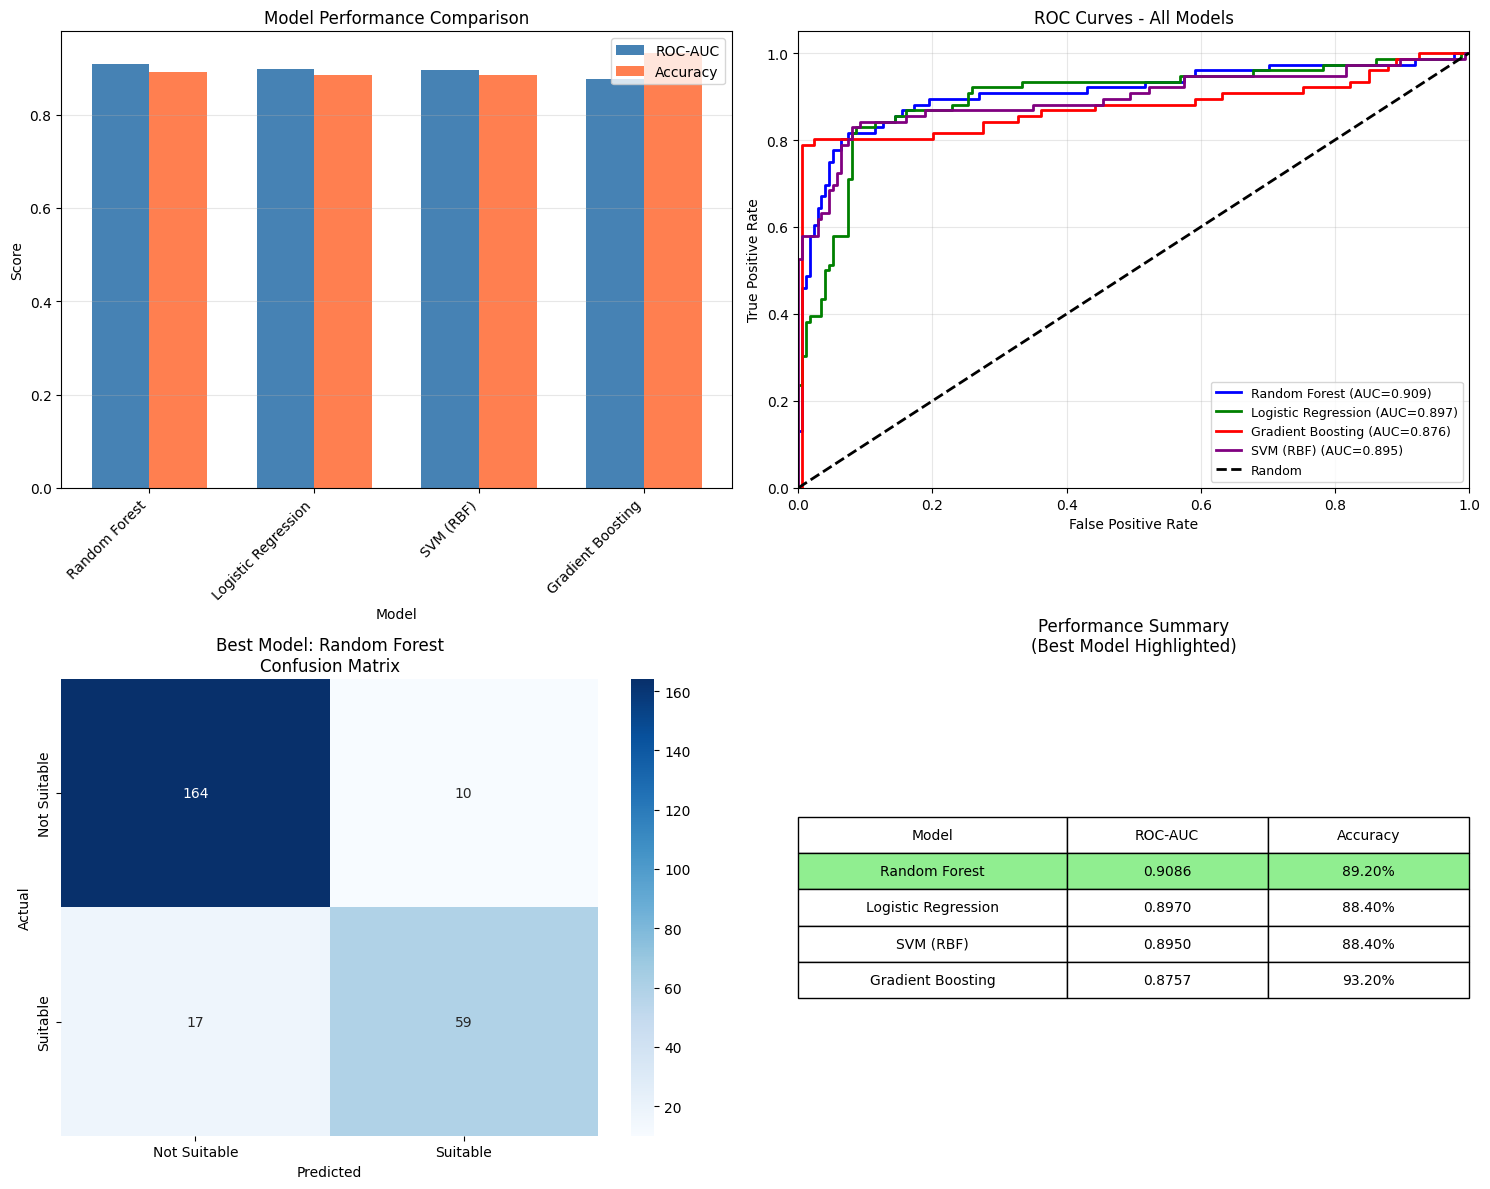

In [23]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))


ax1 = axes[0, 0]
x_pos = np.arange(len(comparison_df))
width = 0.35
ax1.bar(x_pos - width/2, comparison_df['ROC-AUC'], width, label='ROC-AUC', color='steelblue')
ax1.bar(x_pos + width/2, comparison_df['Accuracy'], width, label='Accuracy', color='coral')
ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Model Performance Comparison')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)


ax2 = axes[0, 1]
models_data = [
    ('Random Forest', rf_y_probs, rf_roc, 'blue'),
    ('Logistic Regression', lr_y_probs, lr_roc, 'green'),
    ('Gradient Boosting', gb_y_probs, gb_roc, 'red'),
    ('SVM (RBF)', svm_y_probs, svm_roc, 'purple')
]

for name, probs, roc, color in models_data:
    fpr_temp, tpr_temp, _ = roc_curve(y_test, probs)
    ax2.plot(fpr_temp, tpr_temp, lw=2, label=f'{name} (AUC={roc:.3f})', color=color)

ax2.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves - All Models')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(alpha=0.3)


ax3 = axes[1, 0]
best_cm_map = {
    'Random Forest': confusion_matrix(y_test, rf_y_pred),
    'Logistic Regression': lr_cm,
    'Gradient Boosting': gb_cm,
    'SVM (RBF)': svm_cm
}
best_cm = best_cm_map[best_model_name]
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Not Suitable', 'Suitable'],
            yticklabels=['Not Suitable', 'Suitable'])
ax3.set_title(f'Best Model: {best_model_name}\nConfusion Matrix')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')


ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')
table_data = []
for _, row in comparison_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['ROC-AUC']:.4f}",
        f"{row['Accuracy']*100:.2f}%"
    ])

table = ax4.table(cellText=table_data,
                  colLabels=['Model', 'ROC-AUC', 'Accuracy'],
                  cellLoc='center',
                  loc='center',
                  colWidths=[0.4, 0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)


for i in range(len(table_data)):
    if comparison_df.iloc[i]['Model'] == best_model_name:
        for j in range(3):
            table[(i+1, j)].set_facecolor('#90EE90')

ax4.set_title('Performance Summary\n(Best Model Highlighted)', fontsize=12, pad=20)

plt.tight_layout()
plt.savefig('model_comparison_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved: model_comparison_analysis.png")
plt.show()

 7. Threshold Optimization for Clinical Safety



In [24]:
# Import additional metrics
from sklearn.metrics import precision_score, recall_score

# Get probability predictions from final model
final_y_probs = final_model.predict_proba(X_test)[:, 1]

# Evaluate multiple thresholds
thresholds = [0.3, 0.4, 0.5, 0.6]
threshold_results = []

print("="*80)
print("THRESHOLD ANALYSIS FOR CLINICAL SAFETY")
print("="*80)

for threshold in thresholds:
    # Apply threshold
    y_pred_threshold = (final_y_probs >= threshold).astype(int)
    
    # Calculate metrics
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    tn, fp, fn, tp = cm_threshold.ravel()
    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold)
    
    threshold_results.append({
        'Threshold': threshold,
        'TP': tp,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'Precision': precision,
        'Recall': recall
    })
    
    print(f"\nThreshold: {threshold}")
    print(f"  Confusion Matrix: TN={tn:4d}, FP={fp:4d}, FN={fn:4d}, TP={tp:4d}")
    print(f"  False Positives: {fp:4d} (recommending unsuitable matches)")
    print(f"  False Negatives: {fn:4d} (missing suitable matches)")
    print(f"  Precision: {precision:.4f} (% of predicted suitable that are truly suitable)")
    print(f"  Recall: {recall:.4f} (% of truly suitable that are identified)")

# Create comparison dataframe
threshold_df = pd.DataFrame(threshold_results)
print("\n" + "="*80)
print("THRESHOLD COMPARISON SUMMARY")
print("="*80)
print(threshold_df.to_string(index=False))
print("="*80)

# Recommend safest threshold
# Prioritize minimizing False Positives (unsuitable matches recommended)
recommended_idx = threshold_df['FP'].idxmin()
recommended_threshold = threshold_df.loc[recommended_idx, 'Threshold']

print(f"\n✓ RECOMMENDED THRESHOLD: {recommended_threshold}")
print(f"  Rationale: Minimizes False Positives ({threshold_df.loc[recommended_idx, 'FP']:.0f})")
print(f"  This reduces risk of recommending unsuitable donor-recipient pairs")
print("="*80)

THRESHOLD ANALYSIS FOR CLINICAL SAFETY

Threshold: 0.3
  Confusion Matrix: TN= 153, FP=  21, FN=  13, TP=  63
  False Positives:   21 (recommending unsuitable matches)
  False Negatives:   13 (missing suitable matches)
  Precision: 0.7500 (% of predicted suitable that are truly suitable)
  Recall: 0.8289 (% of truly suitable that are identified)

Threshold: 0.4
  Confusion Matrix: TN= 160, FP=  14, FN=  14, TP=  62
  False Positives:   14 (recommending unsuitable matches)
  False Negatives:   14 (missing suitable matches)
  Precision: 0.8158 (% of predicted suitable that are truly suitable)
  Recall: 0.8158 (% of truly suitable that are identified)

Threshold: 0.5
  Confusion Matrix: TN= 164, FP=  10, FN=  17, TP=  59
  False Positives:   10 (recommending unsuitable matches)
  False Negatives:   17 (missing suitable matches)
  Precision: 0.8551 (% of predicted suitable that are truly suitable)
  Recall: 0.7763 (% of truly suitable that are identified)

Threshold: 0.6
  Confusion Matrix

 8. Model Stability Assessment (Cross-Validation)



In [25]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Perform 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("="*70)
print("STRATIFIED 5-FOLD CROSS-VALIDATION")
print("="*70)
print(f"Model: {best_model_name}")
print(f"Metric: ROC-AUC")
print(f"Folds: 5 (stratified)")
print("-"*70)

# Perform cross-validation
cv_scores = cross_val_score(
    final_model, 
    X, 
    y, 
    cv=cv, 
    scoring='roc_auc',
    n_jobs=-1
)

# Calculate statistics
mean_cv_score = cv_scores.mean()
std_cv_score = cv_scores.std()

print(f"\nCross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean ROC-AUC: {mean_cv_score:.4f}")
print(f"Std Dev:      {std_cv_score:.4f}")
print(f"95% CI:       [{mean_cv_score - 1.96*std_cv_score:.4f}, {mean_cv_score + 1.96*std_cv_score:.4f}]")

# Compare to single test set
print(f"\nSingle Test Set ROC-AUC: {best_roc_auc:.4f}")
print(f"Difference: {abs(best_roc_auc - mean_cv_score):.4f}")

if std_cv_score < 0.05:
    print("\n✓ STABLE: Low variance indicates consistent performance across folds")
else:
    print("\n⚠ CAUTION: High variance suggests performance may be data-dependent")

print("="*70)

STRATIFIED 5-FOLD CROSS-VALIDATION
Model: Random Forest
Metric: ROC-AUC
Folds: 5 (stratified)
----------------------------------------------------------------------

Cross-Validation Scores:
  Fold 1: 0.9046
  Fold 2: 0.8480
  Fold 3: 0.9238
  Fold 4: 0.9363
  Fold 5: 0.8639

Mean ROC-AUC: 0.8953
Std Dev:      0.0341
95% CI:       [0.8285, 0.9621]

Single Test Set ROC-AUC: 0.9086
Difference: 0.0133

✓ STABLE: Low variance indicates consistent performance across folds


 9. Feature Importance Analysis


TOP 10 MOST IMPORTANT FEATURES (Random Forest)
          Feature  Importance
ABO_Compatibility    0.244235
 Donor_Risk_Index    0.232310
        Donor_HTN    0.155589
 Recipient_ABO_AB    0.074414
      Donor_ABO_O    0.066138
         Donor_DM    0.062909
       Donor_eGFR    0.041304
     Donor_ABO_AB    0.020483
    Recipient_PRA    0.020063
  Recipient_ABO_O    0.017991

Visualization saved: feature_importance.png


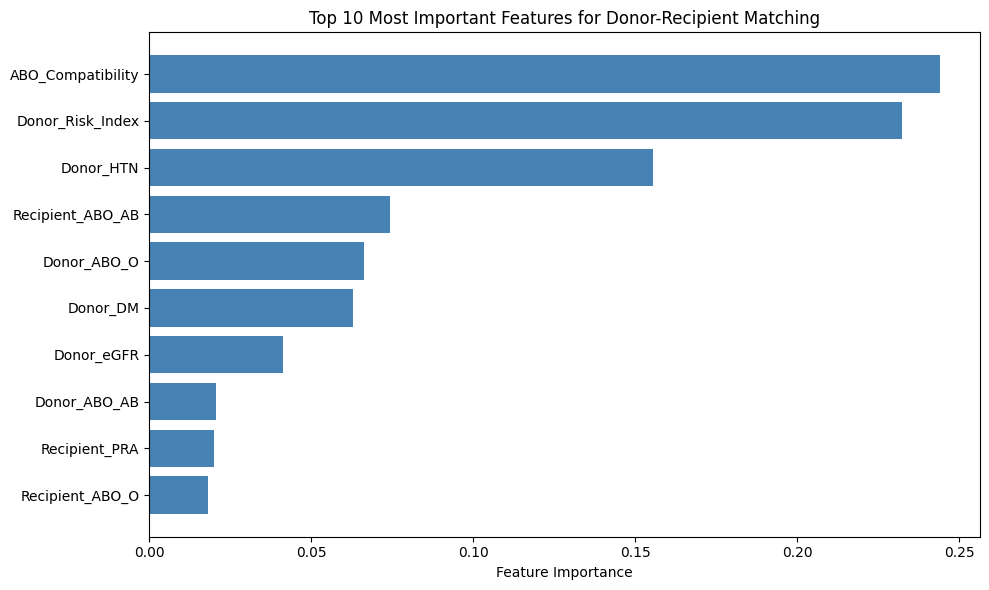

In [26]:
# Extract feature importances from Random Forest
# (Random Forest is always trained, regardless of which model was selected as best)

# Get feature names after preprocessing
feature_names_transformed = []

# Numeric features keep their names
feature_names_transformed.extend(numeric_features)

# Categorical features get one-hot encoded
if len(categorical_features) > 0:
    # Get the encoder from the pipeline
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    feature_names_transformed.extend(cat_feature_names)

# Get Random Forest classifier from pipeline
rf_classifier = model_pipeline.named_steps['classifier']

# Extract feature importances
importances = rf_classifier.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_transformed,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display top 10
print("="*70)
print("TOP 10 MOST IMPORTANT FEATURES (Random Forest)")
print("="*70)
print(feature_importance_df.head(10).to_string(index=False))
print("="*70)

# Visualize top 10
plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(range(len(top_10)), top_10['Importance'], color='steelblue')
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Donor-Recipient Matching')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("\nVisualization saved: feature_importance.png")
plt.show()

 10. Error Analysis and Clinical Safety



In [27]:

# Identify False Positives (predicted suitable but actually not suitable)
final_y_pred = final_model.predict(X_test)

fp_mask = (final_y_pred == 1) & (y_test == 0)
fp_indices = y_test[fp_mask].index

print("="*70)
print("FALSE POSITIVE ANALYSIS")
print("="*70)
print(f"Total False Positives: {fp_mask.sum()}")
print(f"Percentage of test set: {fp_mask.sum() / len(y_test) * 100:.2f}%")
print("-"*70)

if fp_mask.sum() > 0:
    # Get original data for false positives
    fp_samples = X_test.loc[fp_indices].head(5)
    fp_probs = final_y_probs[fp_mask][:5]
    
    print("\nSample of False Positive Cases (up to 5):")
    print("(Model predicted SUITABLE, but actually NOT SUITABLE)\n")
    
    for idx, (sample_idx, row) in enumerate(fp_samples.iterrows(), 1):
        print(f"Case {idx}:")
        print(f"  Predicted Probability: {fp_probs[idx-1]:.4f}")
        print(f"  Sample features (first 5):")
        for col in row.index[:5]:
            print(f"    {col}: {row[col]}")
        print()
    
    print("-"*70)
    
    # Identify False Negatives (predicted not suitable but actually suitable)
    fn_mask = (final_y_pred == 0) & (y_test == 1)
    
    print(f"\nTotal False Negatives: {fn_mask.sum()}")
    print(f"Percentage of test set: {fn_mask.sum() / len(y_test) * 100:.2f}%")
    
else:
    print("\nNo false positives found in test set.")

print("="*70)

FALSE POSITIVE ANALYSIS
Total False Positives: 10
Percentage of test set: 4.00%
----------------------------------------------------------------------

Sample of False Positive Cases (up to 5):
(Model predicted SUITABLE, but actually NOT SUITABLE)

Case 1:
  Predicted Probability: 0.5563
  Sample features (first 5):
    Donor_Age: 32
    Donor_BMI: 23.4
    Donor_eGFR: 60.0
    Donor_HTN: 0
    Donor_DM: 0

Case 2:
  Predicted Probability: 0.5302
  Sample features (first 5):
    Donor_Age: 34
    Donor_BMI: 20.5
    Donor_eGFR: 60.0
    Donor_HTN: 0
    Donor_DM: 0

Case 3:
  Predicted Probability: 0.5020
  Sample features (first 5):
    Donor_Age: 42
    Donor_BMI: 24.2
    Donor_eGFR: 60.0
    Donor_HTN: 0
    Donor_DM: 0

Case 4:
  Predicted Probability: 0.6154
  Sample features (first 5):
    Donor_Age: 25
    Donor_BMI: 21.9
    Donor_eGFR: 66.7
    Donor_HTN: 0
    Donor_DM: 0

Case 5:
  Predicted Probability: 0.5286
  Sample features (first 5):
    Donor_Age: 21
    Donor_BMI: 2

11. SHAP Explainability Analysis

In [28]:
# Initialize SHAP explainer for Random Forest
print("="*70)
print("INITIALIZING SHAP EXPLAINER")
print("="*70)

# Get transformed feature matrix for SHAP
X_test_transformed = final_model.named_steps['preprocessor'].transform(X_test)

# Get feature names after preprocessing
feature_names_transformed = []
feature_names_transformed.extend(numeric_features)

if len(categorical_features) > 0:
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
    feature_names_transformed.extend(cat_feature_names.tolist())

# Extract Random Forest classifier
rf_classifier = final_model.named_steps['classifier']

# Create SHAP explainer
explainer = create_explainer(
    rf_classifier, 
    feature_names_transformed,
    X_background=X_test_transformed[:100]  # Use subset for efficiency
)

print(f"✓ SHAP explainer initialized")
print(f"✓ Feature count: {len(feature_names_transformed)}")
print("="*70)

INITIALIZING SHAP EXPLAINER
✓ SHAP TreeExplainer initialized successfully
✓ SHAP explainer initialized
✓ Feature count: 20


In [29]:
# Compute SHAP values for test set
print("Computing SHAP values for test set...")
shap_values = explainer.compute_shap_values(X_test_transformed)
print(f"✓ SHAP values computed: {shap_values.shape}")

# Get global feature importance
feature_importance_shap = explainer.get_feature_importance(X_test_transformed, top_k=15)

print("\n" + "="*70)
print("TOP 15 FEATURES BY SHAP IMPORTANCE")
print("="*70)
print(feature_importance_shap.to_string(index=False))
print("="*70)

Computing SHAP values for test set...
✓ SHAP values computed: (250, 20, 2)

TOP 15 FEATURES BY SHAP IMPORTANCE
          Feature  Importance
ABO_Compatibility    0.087976
 Donor_Risk_Index    0.061922
        Donor_HTN    0.051489
 Recipient_ABO_AB    0.026817
      Donor_ABO_O    0.021429
         Donor_DM    0.011318
       Donor_eGFR    0.009783
   Dialysis_Years    0.008748
  Recipient_ABO_O    0.008650
     Donor_ABO_AB    0.006983
    Recipient_PRA    0.003969
        Donor_BMI    0.002965
          Age_Gap    0.002586
  Recipient_ABO_A    0.002102
    Recipient_Age    0.002051


In [30]:
# Force reload the SHAP explainer module to get the latest version
import sys
if 'shap_explainer' in sys.modules:
    del sys.modules['shap_explainer']

from shap_explainer import DonorMatchExplainer, create_explainer

# Recreate the explainer with the updated code
explainer = create_explainer(
    rf_classifier, 
    feature_names_transformed,
    X_background=X_test_transformed[:100]
)
print("✓ SHAP explainer reloaded and recreated")

✓ SHAP TreeExplainer initialized successfully
✓ SHAP explainer reloaded and recreated


In [ ]:
# Generate human-readable explanations for sample predictions
print("="*70)
print("SAMPLE PREDICTION EXPLANATIONS")
print("="*70)

# Explain 3 sample predictions
for sample_idx in [0, 1, 2]:
    explanation = explainer.explain_prediction(X_test_transformed, sample_idx)
    
    actual_label = "Suitable" if y_test.iloc[sample_idx] == 1 else "Not Suitable"
    predicted_label = "Suitable" if final_model.predict(X_test.iloc[[sample_idx]])[0] == 1 else "Not Suitable"
    
    print(f"\n{'='*70}")
    print(f"SAMPLE {sample_idx + 1}")
    print(f"{'='*70}")
    print(f"Actual: {actual_label} | Predicted: {predicted_label}")
    print(f"\nTop Contributing Features:")
    
    for i, exp in enumerate(explanation['human_explanations'][:5], 1):
        print(f"  {i}. {exp}")
    
print("\n" + "="*70)

SAMPLE PREDICTION EXPLANATIONS

SAMPLE 1
Actual: Suitable | Predicted: Suitable

Top Contributing Features:
  1. ABO blood type compatibility ensured safe transfusion
  2. Low donor risk profile (DRI: -1.82) indicated optimal organ
  3. Recipient_ABO_AB (value: 1.00) had a positive impact on the prediction
  4. No donor hypertension history improved organ quality
  5. Dialysis_Years (value: 0.62) had a negative impact on the prediction

SAMPLE 2
Actual: Not Suitable | Predicted: Not Suitable

Top Contributing Features:
  1. Elevated donor risk profile (DRI: 0.24) raised transplant concerns
  2. ABO blood type compatibility ensured safe transfusion
  3. Donor diabetes history increased risk of diabetic nephropathy transmission
  4. Recipient_ABO_AB (value: 1.00) had a positive impact on the prediction
  5. No donor hypertension history improved organ quality

SAMPLE 3
Actual: Suitable | Predicted: Not Suitable

Top Contributing Features:
  1. Elevated donor risk profile (DRI: 0.60) rais

: 